This code serves as the foundational preprocessing layer for structural bioinformatics, designed to translate complex 3D protein models into a structured numerical format for downstream analysis. By utilising the PDBParser from the Biopython library, the script programmatically reads a .pdb file, specifically the Cereblon structure 4OO2, to extract the raw spatial coordinates of every atom determined via experimental crystallography. The logic specifically targets the Alpha-Carbon (CA) atoms, which act as the geometric 'spine' or backbone of the protein, effectively filtering out the high-frequency 'noise' of moving side chains to reveal the essential fold. Finally, these extracted coordinates are converted into a NumPy array, transforming the biological structure into a mathematical matrix that can be used for calculating distance heatmaps, identifying domain boundaries, or measuring conformational tightening within the E3 ligase system.

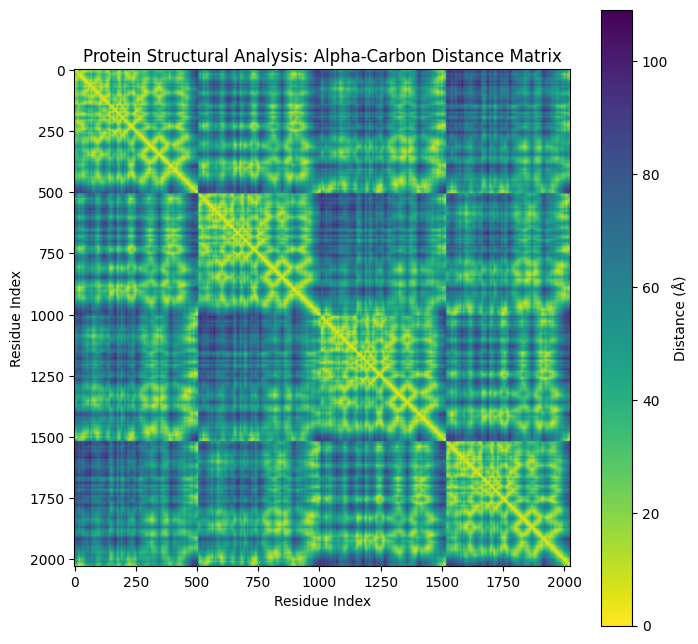

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from Bio.PDB import PDBParser

# 1. Parse the Protein Structure
# From https://www.rcsb.org/ take 
parser = PDBParser(QUIET=True)
structure = parser.get_structure('protein', '4OO2.pdb') # Replace with your file

# 2. Extract Alpha-Carbon (CA) coordinates
# These represent the 'backbone' pattern of the protein
atoms = []
for model in structure:
    for chain in model:
        for residue in chain:
            if 'CA' in residue:
                atoms.append(residue['CA'].get_coord())

coords = np.array(atoms)

# 3. Calculate the Distance Matrix
# This detects the spatial relationships between every atom in the structure
def calculate_distance_matrix(coords):
    diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]
    return np.sqrt(np.sum(diff**2, axis=-1))

dist_matrix = calculate_distance_matrix(coords)

# 4. Visualise the Structural Pattern
plt.figure(figsize=(8, 8))
plt.imshow(dist_matrix, cmap='viridis_r')
plt.colorbar(label='Distance (Å)')
plt.title('Protein Structural Analysis: Alpha-Carbon Distance Matrix')
plt.xlabel('Residue Index')
plt.ylabel('Residue Index')
plt.show()


This heatmap displays an Alpha-Carbon Distance Matrix, a foundational tool in structural biology for identifying the mechanical logic and spatial organisation of a protein. By mapping the Euclidean distance between every pair of residues in a 2000-atom sequence, the visualisation reveals structural patterns that are invisible in a simple 3D model. The bright yellow diagonal represents the zero-distance baseline of residues compared to themselves, while the dark purple off-diagonal regions indicate distant segments in the primary sequence that are physically isolated in space. Conversely, the smaller yellow clusters and distinct rectangular regions away from the diagonal highlight domain folding and tertiary contacts, where residues far apart in the sequence have come together to form stable functional units. In the context of the CRL4/CRBN system, such a matrix is essential for detecting how a molecular glue alters the protein's spatial orientation, allowing researchers to pinpoint exactly where structural conformational tightening or recruitment occurs at an atomic level.